# Register Shift in Grounded QA

## What this notebook does
1. Loads the cleaned dataset with **neutral / formal / informal** question variants.
2. Converts the data into **long format** so each row is one `(example, register)` prompt.
3. Loads a single instruction-tuned model.
4. Runs grounded QA with a fixed prompt.
5. Scores outputs with **exact match**, **lenient match**, and **abstention**.
6. Produces paper-ready tables for:
   - overall results by register
   - results by context variant
   - paired register-difference summaries
   - qualitative error-analysis candidates

## Before you run this notebook
- Use a **GPU runtime** in Colab if possible.
- Upload `confiqa_register_eval_cleaned.csv` to the Colab session.
- The notebook assumes the cleaned CSV filename is exactly:

```python
confiqa_register_eval_cleaned.csv
```


## 1. Install dependencies

In [1]:
!pip install -q "transformers==4.41.2" datasets pandas tqdm accelerate sentencepiece matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.9 MB/s eta 0:00:00


## 2. Imports and basic settings

In [2]:
import ast
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Experiment settings
CLEAN_DATASET_PATH = "confiqa_register_eval_cleaned.csv"
MODEL_NAME = "google/flan-t5-base"
MAX_NEW_TOKENS = 40
USE_GPU = torch.cuda.is_available()

print("GPU available:", USE_GPU)

GPU available: False


## 3. Load the cleaned dataset

The cleaned dataset should already contain:
- `question_neutral`
- `question_formal`
- `question_informal`

The rest of the notebook builds the actual experiment from this file.

In [3]:
df = pd.read_csv(CLEAN_DATASET_PATH)

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (150, 19)


,example_id,source_dataset,subset,split,source_row_idx,context_variant,question_original,question_neutral,question_formal,question_informal,context,gold_answer,gold_aliases,support_piece,support_path,support_path_labeled,triple,rewrite_generation_source,rewrite_needs_manual_check
0,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,Where did Ernest Hemingway work?,Where did Ernest Hemingway work?,"According to the passage, where was Ernest Hem...","Based on the passage, where'd Ernest Hemingway...","Ernest Hemingway, the renowned author, resided...",Alassio,"[""Alassio""]",The work location of Ernest Hemingway is Alassio.,"[('Q23434', 'P937', 'Q270482')]","[('Ernest Hemingway', 'work location', 'Alassi...","('Q23434', 'P937', 'Q270482')",assistant_pattern_edit,False
1,confiqa_qa_train_00000_modified,RajMaheshwari/ConFiQA,QA,train,0,modified,Where did Ernest Hemingway work?,Where did Ernest Hemingway work?,"According to the passage, where was Ernest Hem...","Based on the passage, where'd Ernest Hemingway...","Ernest Hemingway, the renowned author, resided...",United States of America,"[""United States of America"", ""United States"", ...",The work location of Ernest Hemingway is Unite...,"[('Q23434', 'P937', 'Q30')]","[('Ernest Hemingway', 'work location', 'United...","('Q23434', 'P937', 'Q30')",assistant_pattern_edit,False
2,confiqa_qa_train_00001_original,RajMaheshwari/ConFiQA,QA,train,1,original,What position does Ron Klain hold related to t...,What position does Ron Klain hold related to t...,"According to the passage, what position does R...","Based on the passage, what job does Ron Klain ...",Ron Klain served as the Chief of Staff to the ...,Chief of Staff to the Vice President of the Un...,"[""Chief of Staff to the Vice President of the ...",Ron Klain held the position of Chief of Staff ...,"[('Q649898', 'P39', 'Q5097041')]","[('Ron Klain', 'position held', 'Chief of Staf...","('Q649898', 'P39', 'Q5097041')",assistant_pattern_edit,False
3,confiqa_qa_train_00001_modified,RajMaheshwari/ConFiQA,QA,train,1,modified,What position does Ron Klain hold related to t...,What position does Ron Klain hold related to t...,"According to the passage, what position does R...","Based on the passage, what job does Ron Klain ...",Ron Klain served as the Special Envoy of the S...,Special Envoy of the Secretary-General,"[""Special Envoy of the Secretary-General""]",Ron Klain held the position of Special Envoy o...,"[('Q649898', 'P39', 'Q7574548')]","[('Ron Klain', 'position held', 'Special Envoy...","('Q649898', 'P39', 'Q7574548')",assistant_pattern_edit,False
4,confiqa_qa_train_00002_original,RajMaheshwari/ConFiQA,QA,train,2,original,What record label is Missy Elliott associated ...,What record label is Missy Elliott associated ...,"According to the passage, with which record la...","Based on the passage, what label is Missy Elli...",The Goldmind Inc. is a record label founded by...,The Goldmind Inc.,"[""The Goldmind Inc."", ""Goldmind""]",Missy Elliott is under the record label The Go...,"[('Q155079', 'P264', 'Q7737132')]","[('Missy Elliott', 'record label', 'The Goldmi...","('Q155079', 'P264', 'Q7737132')",assistant_pattern_edit,False


## 4. Convert the dataset to long format

Each original row contains three register versions of the same question.
This cell expands each row into **three experiment rows**:
- neutral
- formal
- informal


In [4]:
records = []

for _, row in df.iterrows():
    for register in ["neutral", "formal", "informal"]:
        aliases = row["gold_aliases"]
        try:
            aliases = ast.literal_eval(aliases) if isinstance(aliases, str) else []
            if not isinstance(aliases, list):
                aliases = []
        except:
            aliases = []

        records.append({
            "example_id": row["example_id"],
            "source_dataset": row["source_dataset"],
            "subset": row["subset"],
            "split": row["split"],
            "source_row_idx": row["source_row_idx"],
            "context_variant": row["context_variant"],
            "register": register,
            "question": row[f"question_{register}"],
            "context": row["context"],
            "gold_answer": row["gold_answer"],
            "gold_aliases": aliases,
        })

exp_df = pd.DataFrame(records)
exp_df.to_csv("confiqa_register_eval_long.csv", index=False)

print("Long-format experiment shape:", exp_df.shape)
display(exp_df.head())

Long-format experiment shape: (450, 11)


,example_id,source_dataset,subset,split,source_row_idx,context_variant,register,question,context,gold_answer,gold_aliases
0,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,neutral,Where did Ernest Hemingway work?,"Ernest Hemingway, the renowned author, resided...",Alassio,[Alassio]
1,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,formal,"According to the passage, where was Ernest Hem...","Ernest Hemingway, the renowned author, resided...",Alassio,[Alassio]
2,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,informal,"Based on the passage, where'd Ernest Hemingway...","Ernest Hemingway, the renowned author, resided...",Alassio,[Alassio]
3,confiqa_qa_train_00000_modified,RajMaheshwari/ConFiQA,QA,train,0,modified,neutral,Where did Ernest Hemingway work?,"Ernest Hemingway, the renowned author, resided...",United States of America,"[United States of America, United States, the ..."
4,confiqa_qa_train_00000_modified,RajMaheshwari/ConFiQA,QA,train,0,modified,formal,"According to the passage, where was Ernest Hem...","Ernest Hemingway, the renowned author, resided...",United States of America,"[United States of America, United States, the ..."


## 5. Load the model

This notebook uses a single instruction-tuned model for the main experiment.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Running on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Running on: cpu


## 6. Define the prompt and generation function

The model is instructed to answer **using only the passage** and to abstain with
`insufficient evidence` when the context does not support a confident answer.

In [6]:
def build_prompt(context, question):
    return f"""Answer the question using only the provided passage.
If the passage does not contain enough information, answer exactly: insufficient evidence.

Passage:
{context}

Question:
{question}

Answer:"""

def generate_answer(context, question, max_new_tokens=MAX_NEW_TOKENS):
    prompt = build_prompt(context, question)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return text

## 7. Define scoring functions

This section creates:
- **exact correctness**
- **lenient correctness**
- **abstention detection**

The lenient metric helps with near-matches such as minor phrasing differences.

In [7]:
def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s

def parse_aliases(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else []
    except:
        return []

def is_correct(pred, gold, aliases):
    pred_n = normalize_text(pred)
    gold_n = normalize_text(gold)

    if pred_n == gold_n:
        return 1

    for a in aliases:
        if pred_n == normalize_text(a):
            return 1

    return 0

def is_correct_lenient(pred, gold, aliases):
    pred_n = normalize_text(pred)
    gold_n = normalize_text(gold)

    if pred_n == gold_n or pred_n in gold_n or gold_n in pred_n:
        return 1

    for a in aliases:
        a_n = normalize_text(a)
        if pred_n == a_n or pred_n in a_n or a_n in pred_n:
            return 1

    return 0

def is_abstain(pred):
    return normalize_text(pred) == "insufficient evidence"

## 8. Run the full experiment

This cell runs the model on **all rows** in the long-format dataset and stores the predictions.

In [8]:
full_df = exp_df.copy()

predictions = []
for _, row in tqdm(full_df.iterrows(), total=len(full_df), desc="Running full dataset"):
    pred = generate_answer(row["context"], row["question"])
    predictions.append(pred)

full_df["prediction"] = predictions

full_df["gold_aliases"] = full_df["gold_aliases"].apply(parse_aliases)
full_df["correct"] = full_df.apply(
    lambda r: is_correct(r["prediction"], r["gold_answer"], r["gold_aliases"]),
    axis=1
)
full_df["correct_lenient"] = full_df.apply(
    lambda r: is_correct_lenient(r["prediction"], r["gold_answer"], r["gold_aliases"]),
    axis=1
)
full_df["abstained"] = full_df["prediction"].apply(is_abstain)

full_df.to_csv("full_register_results.csv", index=False)

print("Saved full_register_results.csv")
display(full_df.head())

Running full dataset: 100%|██████████| 450/450 [08:40<00:00,  1.16s/it]

Saved full_register_results.csv


,example_id,source_dataset,subset,split,source_row_idx,context_variant,register,question,context,gold_answer,gold_aliases,prediction,correct,correct_lenient,abstained
0,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,neutral,Where did Ernest Hemingway work?,"Ernest Hemingway, the renowned author, resided...",Alassio,[Alassio],insufficient evidence,0,0,True
1,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,formal,"According to the passage, where was Ernest Hem...","Ernest Hemingway, the renowned author, resided...",Alassio,[Alassio],insufficient evidence,0,0,True
2,confiqa_qa_train_00000_original,RajMaheshwari/ConFiQA,QA,train,0,original,informal,"Based on the passage, where'd Ernest Hemingway...","Ernest Hemingway, the renowned author, resided...",Alassio,[Alassio],"Alassio, Italy",0,1,False
3,confiqa_qa_train_00000_modified,RajMaheshwari/ConFiQA,QA,train,0,modified,neutral,Where did Ernest Hemingway work?,"Ernest Hemingway, the renowned author, resided...",United States of America,"[United States of America, United States, the ...","United States of America, Italy",0,1,False
4,confiqa_qa_train_00000_modified,RajMaheshwari/ConFiQA,QA,train,0,modified,formal,"According to the passage, where was Ernest Hem...","Ernest Hemingway, the renowned author, resided...",United States of America,"[United States of America, United States, the ...","United States of America, Italy",0,1,False


### 9. Main results table

This is the primary table:
- one row per register
- exact accuracy
- lenient accuracy
- abstention rate

In [10]:
main_table = full_df.groupby("register").agg(
    n=("example_id", "count"),
    accuracy_exact=("correct", "mean"),
    accuracy_lenient=("correct_lenient", "mean"),
    abstention_rate=("abstained", "mean"),
).reset_index()

for col in ["accuracy_exact", "accuracy_lenient", "abstention_rate"]:
    main_table[col] = (100 * main_table[col]).round(1)

main_table = main_table.sort_values("register")

main_table_display = main_table.rename(columns={
    "register": "Register",
    "n": "N",
    "accuracy_exact": "Exact Acc. (%)",
    "accuracy_lenient": "Lenient Acc. (%)",
    "abstention_rate": "Abstention (%)"
})

display(main_table_display)
main_table.to_csv("table_main_results.csv", index=False)

,Register,N,Exact Acc. (%),Lenient Acc. (%),Abstention (%)
0,formal,150,77.3,86.0,2.0
1,informal,150,76.7,85.3,2.7
2,neutral,150,77.3,86.0,2.7


## 10. Results by context variant

This table splits results by:
- `original` context
- `modified` context


In [11]:
variant_table = full_df.groupby(["context_variant", "register"]).agg(
    n=("example_id", "count"),
    accuracy_exact=("correct", "mean"),
    accuracy_lenient=("correct_lenient", "mean"),
    abstention_rate=("abstained", "mean"),
).reset_index()

for col in ["accuracy_exact", "accuracy_lenient", "abstention_rate"]:
    variant_table[col] = (100 * variant_table[col]).round(1)

variant_table = variant_table.sort_values(["context_variant", "register"])

display(variant_table)
variant_table.to_csv("table_variant_results.csv", index=False)

,context_variant,register,n,accuracy_exact,accuracy_lenient,abstention_rate
0,modified,formal,75,80.0,86.7,0.0
1,modified,informal,75,77.3,86.7,4.0
2,modified,neutral,75,77.3,85.3,2.7
3,original,formal,75,74.7,85.3,4.0
4,original,informal,75,76.0,84.0,1.3
5,original,neutral,75,77.3,86.7,2.7


## 11. Paired register-difference summary

Each `(example_id, context_variant)` group appears in three registers.
This cell counts how often correctness or abstention changes across those paired register versions.

In [12]:
paired = full_df[[
    "example_id", "context_variant", "register",
    "question", "context", "gold_answer", "prediction",
    "correct", "correct_lenient", "abstained"
]].sort_values(["example_id", "context_variant", "register"])

group_summary = paired.groupby(["example_id", "context_variant"]).agg(
    exact_varies=("correct", lambda x: x.nunique() > 1),
    lenient_varies=("correct_lenient", lambda x: x.nunique() > 1),
    abstention_varies=("abstained", lambda x: x.nunique() > 1),
).reset_index()

paired_diff_summary = pd.DataFrame({
    "metric": ["exact correctness", "lenient correctness", "abstention"],
    "num_groups_with_difference": [
        int(group_summary["exact_varies"].sum()),
        int(group_summary["lenient_varies"].sum()),
        int(group_summary["abstention_varies"].sum()),
    ],
    "num_total_groups": [len(group_summary)] * 3
})

paired_diff_summary["percent_groups_with_difference"] = (
    100 * paired_diff_summary["num_groups_with_difference"] / paired_diff_summary["num_total_groups"]
).round(1)

display(paired_diff_summary)
paired_diff_summary.to_csv("table_paired_diff_summary.csv", index=False)

,metric,num_groups_with_difference,num_total_groups,percent_groups_with_difference
0,exact correctness,12,150,8.0
1,lenient correctness,13,150,8.7
2,abstention,7,150,4.7


## 12. Collect register-sensitive examples for qualitative analysis

Useful examples for:
- groups where correctness changes across registers
- groups where abstention changes across registers

In [13]:
interesting_groups = group_summary[
    group_summary["lenient_varies"] | group_summary["abstention_varies"]
][["example_id", "context_variant"]]

interesting_examples = paired.merge(
    interesting_groups,
    on=["example_id", "context_variant"]
).sort_values(["example_id", "context_variant", "register"])

display(
    interesting_examples[[
        "example_id", "context_variant", "register",
        "question", "gold_answer", "prediction",
        "correct", "correct_lenient", "abstained"
    ]].head(30)
)

interesting_examples.to_csv("error_analysis_candidates.csv", index=False)
print("Saved error_analysis_candidates.csv")

,example_id,context_variant,register,question,gold_answer,prediction,correct,correct_lenient,abstained
0,confiqa_qa_train_00000_original,original,formal,"According to the passage, where was Ernest Hem...",Alassio,insufficient evidence,0,0,True
1,confiqa_qa_train_00000_original,original,informal,"Based on the passage, where'd Ernest Hemingway...",Alassio,"Alassio, Italy",0,1,False
2,confiqa_qa_train_00000_original,original,neutral,Where did Ernest Hemingway work?,Alassio,insufficient evidence,0,0,True
3,confiqa_qa_train_00003_original,original,formal,"According to the passage, who performed Sarrai...",S. Thaman,insufficient evidence,0,0,True
4,confiqa_qa_train_00003_original,original,informal,"Based on the passage, who was the performer fo...",S. Thaman,S. Thaman,1,1,False
5,confiqa_qa_train_00003_original,original,neutral,Who is the performer of Sarrainodu?,S. Thaman,S. Thaman,1,1,False
6,confiqa_qa_train_00005_modified,modified,formal,"According to the passage, who employs Dominiqu...",First Boston,First Boston,1,1,False
7,confiqa_qa_train_00005_modified,modified,informal,"Based on the passage, who does Dominique Strau...",First Boston,International Monetary Fund,0,0,False
8,confiqa_qa_train_00005_modified,modified,neutral,Who is the employer of Dominique Strauss-Kahn?,First Boston,First Boston,1,1,False
9,confiqa_qa_train_00005_original,original,formal,"According to the passage, who employs Dominiqu...",Sciences Po,insufficient evidence,0,0,True


Saved error_analysis_candidates.csv


## 13. Collect stable failures

These examples failed in all three registers.

In [14]:
stable_failure_groups = paired.groupby(["example_id", "context_variant"]).filter(
    lambda g: (g["correct_lenient"] == 0).all()
)

display(
    stable_failure_groups[[
        "example_id", "context_variant", "register",
        "question", "gold_answer", "prediction",
        "correct_lenient"
    ]].head(30)
)

stable_failure_groups.to_csv("stable_failures.csv", index=False)
print("Saved stable_failures.csv")

,example_id,context_variant,register,question,gold_answer,prediction,correct_lenient
31,confiqa_qa_train_00005_original,original,formal,"According to the passage, who employs Dominiqu...",Sciences Po,insufficient evidence,0
32,confiqa_qa_train_00005_original,original,informal,"Based on the passage, who does Dominique Strau...",Sciences Po,International Monetary Fund,0
30,confiqa_qa_train_00005_original,original,neutral,Who is the employer of Dominique Strauss-Kahn?,Sciences Po,International Monetary Fund,0
58,confiqa_qa_train_00009_modified,modified,formal,"According to the passage, of which country is ...",Kingdom of France,Kingdom of Kingdom of Kingdom of Kingdom of Ki...,0
59,confiqa_qa_train_00009_modified,modified,informal,"Based on the passage, what country does Avril ...",Kingdom of France,Kingdom of Kingdom of Kingdom of Kingdom of Ki...,0
57,confiqa_qa_train_00009_modified,modified,neutral,What country is Avril Lavigne a citizen of?,Kingdom of France,Kingdom of Kingdom of Kingdom of Kingdom of Ki...,0
76,confiqa_qa_train_00012_modified,modified,formal,"According to the passage, with which musical g...",psychological thriller film,rock,0
77,confiqa_qa_train_00012_modified,modified,informal,"Based on the passage, what kind of music is Wa...",psychological thriller film,"rock, jazz, and pop sensibilities",0
75,confiqa_qa_train_00012_modified,modified,neutral,What genre of music is Walter Becker associate...,psychological thriller film,"rock, jazz, and pop",0
73,confiqa_qa_train_00012_original,original,formal,"According to the passage, with which musical g...",crossover jazz,rock,0


Saved stable_failures.csv


## 14. Quick plots


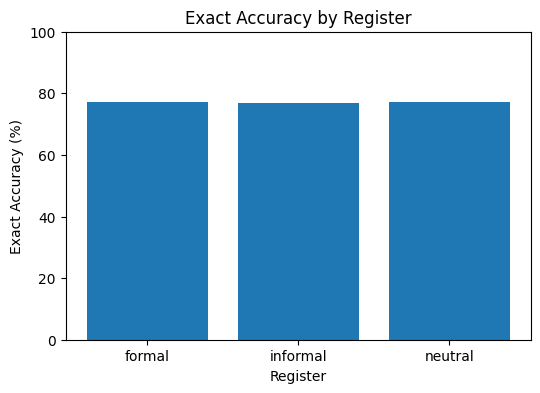

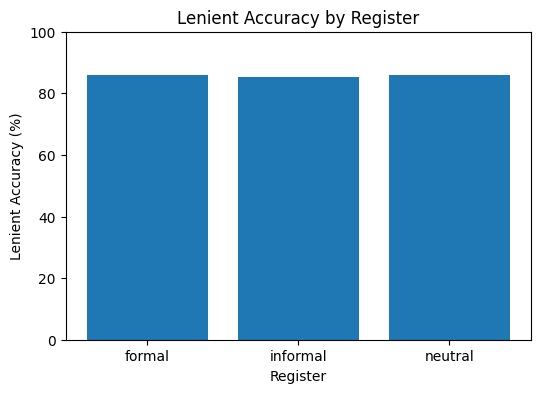

In [15]:
plot_df = main_table.copy()

plt.figure(figsize=(6, 4))
plt.bar(plot_df["register"], plot_df["accuracy_exact"])
plt.ylabel("Exact Accuracy (%)")
plt.xlabel("Register")
plt.title("Exact Accuracy by Register")
plt.ylim(0, 100)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(plot_df["register"], plot_df["accuracy_lenient"])
plt.ylabel("Lenient Accuracy (%)")
plt.xlabel("Register")
plt.title("Lenient Accuracy by Register")
plt.ylim(0, 100)
plt.show()

## 15. Final checklist

### Saved files
- `confiqa_register_eval_long.csv`
- `full_register_results.csv`
- `table_main_results.csv`
- `table_variant_results.csv`
- `table_paired_diff_summary.csv`
- `error_analysis_candidates.csv`
- `stable_failures.csv`

### Key outputs for the paper
- overall results by register
- original vs modified context breakdown
- paired register-difference summary
- qualitative examples for error analysis
